# 📊 Stock Market Analyzer

This project fetches live stock market data dynamically and performs financial analysis using Python.

It includes:
- Live data retrieval
- Moving average analysis
- Multi-stock comparison
- Performance normalization
- Volatility analysis

Tools Used: Python, pandas, matplotlib, yfinance

## 1️⃣ Fetching Live Stock Data

This section retrieves the latest 1-year stock data dynamically using the yfinance API.

In [11]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [12]:
# Get today's date
end_date = datetime.today()

# Get date 1 year ago
start_date = end_date - timedelta(days=365)

stock = yf.download("AAPL", start=start_date, end=end_date)

stock.tail()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-03-23,251.490005,254.600006,250.279999,253.970001,40546100
2026-03-24,251.639999,254.830002,249.550003,250.350006,45152300
2026-03-25,252.619995,255.000000,251.600006,254.100006,28476700
2026-03-26,252.889999,257.000000,250.770004,252.119995,41702500
2026-03-27,252.315002,255.492996,251.800003,253.910004,17777278


## 2️⃣ Moving Average Analysis

We calculate the 20-day moving average to analyze short-term price trends and smooth out fluctuations.

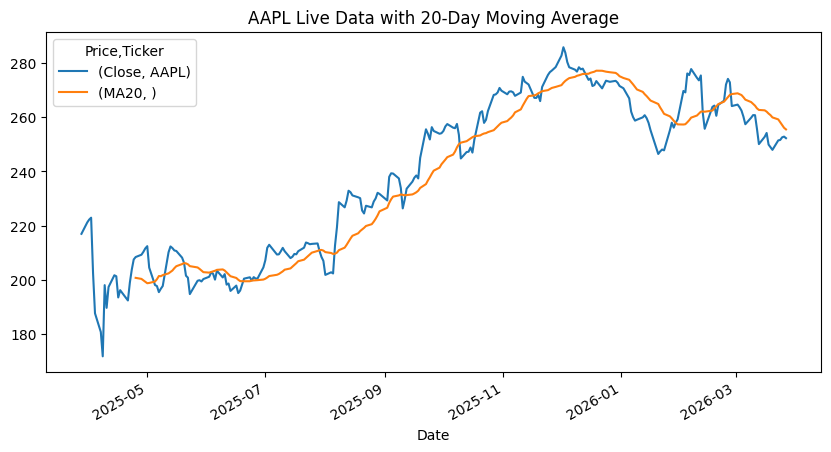

In [13]:
#moving avaerage 
stock["MA20"] = stock["Close"].rolling(window=20).mean()

stock[["Close", "MA20"]].plot(figsize=(10,5))
plt.title("AAPL Live Data with 20-Day Moving Average")
plt.show()

## 3️⃣ Daily Returns Analysis

Daily return represents the percentage change in stock price from one day to the next.

It is calculated using:

Daily Return = (Today's Close - Yesterday's Close) / Yesterday's Close

This metric helps measure:
- Short-term performance
- Price fluctuations
- Risk level

Daily returns are essential for volatility and risk analysis.

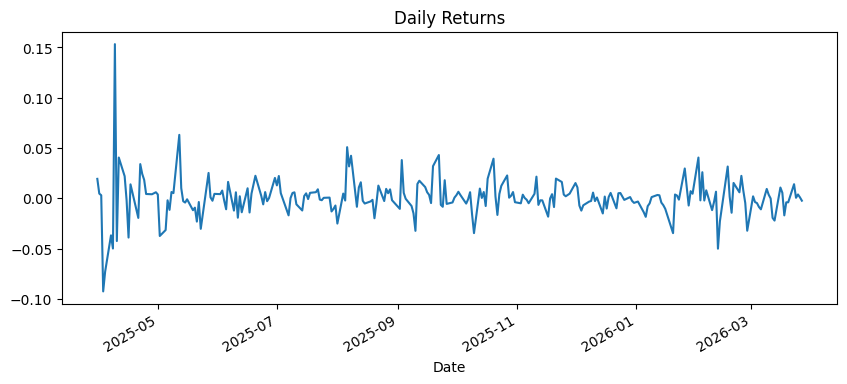

Latest Closing Price: Ticker
AAPL    252.315002
Name: 2026-03-27 00:00:00, dtype: float64
Average Daily Return: 0.0007986617805668846


In [14]:
#daily returns 
stock["Daily Return"] = stock["Close"].pct_change()

stock["Daily Return"].plot(figsize=(10,4))
plt.title("Daily Returns")
plt.show()
print("Latest Closing Price:", stock["Close"].iloc[-1])
print("Average Daily Return:", stock["Daily Return"].mean())

## 4️⃣ Multi-Stock Comparison

In this section, we compare multiple stocks to evaluate their relative performance over time.

This helps answer questions like:
- Which stock performed better?
- Which stock was more stable?
- Which stock showed higher growth?

In [7]:
# Define stock list
tickers = ["AAPL", "MSFT", "GOOGL"]

# Download last 1 year dynamically
multi_stock = yf.download(tickers, start=start_date, end=end_date)["Close"]

multi_stock.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,GOOGL,MSFT
Date,,,
2025-03-28,216.954422,153.796722,375.922089
2025-03-31,221.166061,154.105637,372.537994
2025-04-01,222.221466,156.527252,379.286377
2025-04-02,222.918411,156.497345,379.236725
2025-04-03,202.308258,150.199188,370.275299


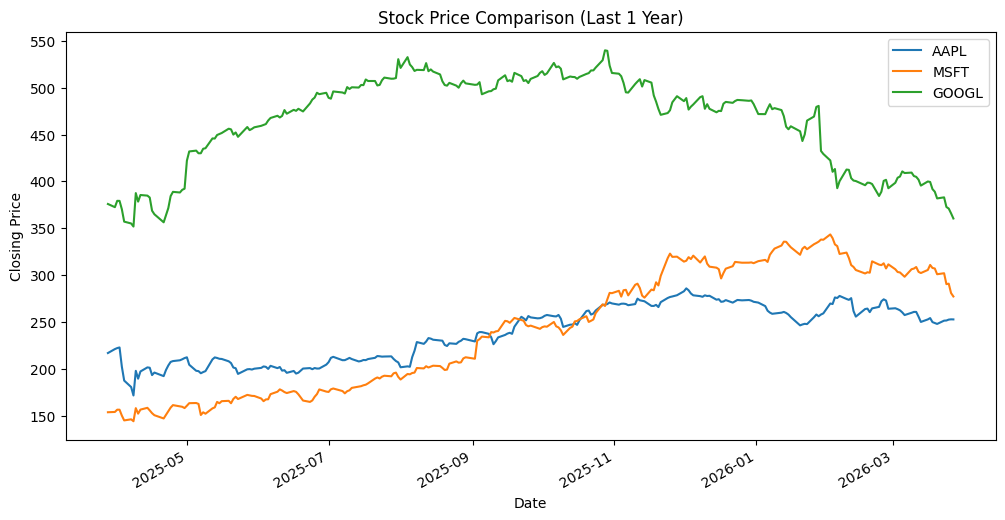

In [8]:
multi_stock.plot(figsize=(12,6))
plt.title("Stock Price Comparison (Last 1 Year)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend(tickers)
plt.show()

## 5️⃣ Performance Normalization

Since stocks have different price ranges, we normalize their prices to allow fair comparison.

Normalization sets the starting value of each stock to 1, enabling percentage-based performance comparison.

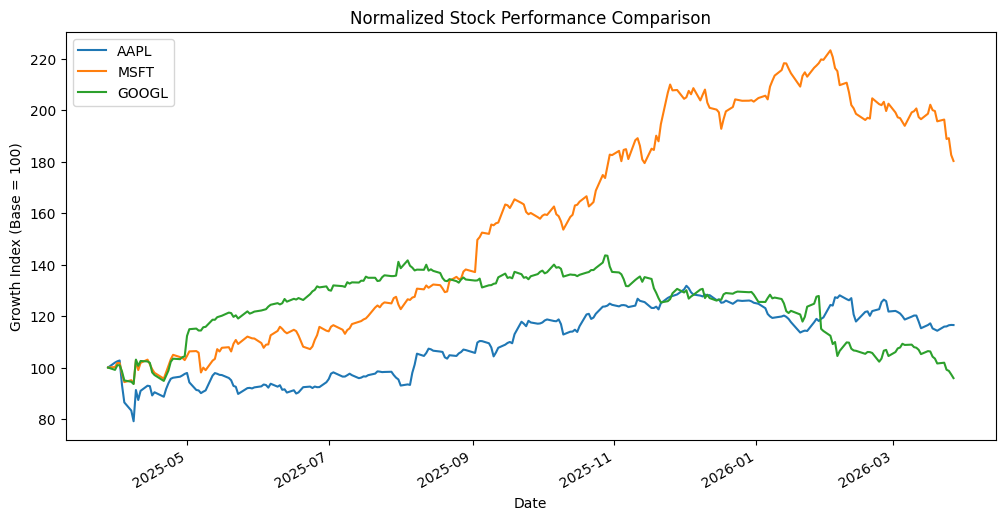

In [9]:
normalized = multi_stock / multi_stock.iloc[0] * 100

normalized.plot(figsize=(12,6))
plt.title("Normalized Stock Performance Comparison")
plt.xlabel("Date")
plt.ylabel("Growth Index (Base = 100)")
plt.legend(tickers)
plt.show()

## 6️⃣ Volatility Analysis

Volatility measures how much a stock's price fluctuates over time.

We calculate volatility using the standard deviation of daily returns.

Higher volatility indicates:
- Higher risk
- Larger price swings

Lower volatility indicates:
- More stability
- Lower risk

In [10]:
volatility = multi_stock.pct_change().std()

print("Volatility (Standard Deviation of Daily Returns):")
print(volatility)

Volatility (Standard Deviation of Daily Returns):
Ticker
AAPL     0.019907
GOOGL    0.019030
MSFT     0.016562
dtype: float64


## 📌 Conclusion

This project demonstrates how live financial data can be analyzed programmatically to extract trends, compare performance, and evaluate risk.

It showcases:
- Data handling skills
- Financial understanding
- Analytical thinking
- Visualization ability

The project can be extended into a financial dashboard or decision-support tool for investors.